# Last Visible Estimator y Clipping Thoracolumbar Explicado - Colab

Este notebook es la siguiente iteracion del pipeline para hacer el modelo lo mas
util posible en la identificacion de vertebras toracicas y lumbares.

## Problema que queremos resolver

En la etapa anterior vimos que:

- la primera vertebra visible se estima bastante bien
- el problema real esta en la **ultima vertebra visible**
- el modelo multiclase tiende a sobreextender la secuencia hacia `L5`

## Idea de esta version

En lugar de predecir el rango completo, nos concentramos en la tarea dificil:

- predecir solo `last_visible_idx`

Para eso combinamos dos tipos de evidencia:

1. la ROI espinal en imagen
2. features anatomicas extraidas de la prediccion multiclase actual

Luego usamos la ultima vertebra visible predicha para recortar la mascara.

## Objetivo del notebook

1. construir el target supervisado `last_visible_idx`
2. generar features anatomicas a partir del modelo multiclase actual
3. entrenar un estimador mas especializado
4. comparar:
   - `raw`
   - `range_pred_clip` anterior como referencia
   - `last_pred_clip`
   - `oracle_clip`

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` si en tu Google Drive la carpeta tiene otro nombre o ruta.

In [1]:
import os
from pathlib import Path

#try:
    #from google.colab import drive  # type: ignore
    #drive.mount('/content/drive')
#except Exception as exc:
    #print('No se detecto entorno Colab o Drive ya estaba montado:', exc)

PROJECT_ROOT = Path('./Scoliosis_Dataset')
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'No existe PROJECT_ROOT={PROJECT_ROOT}. Ajusta esta ruta a tu carpeta real en Google Drive.'
    )

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())

Working directory: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset


## 1. Librerias y configuracion general

Esta etapa reutiliza:

- modelo binario ya entrenado
- mejor modelo multiclase `partial`

y agrega un nuevo modelo especializado para estimar `last_visible_idx`.

In [2]:
from __future__ import annotations

import copy
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CWD = Path.cwd()

ROOT_CANDIDATES = [
    CWD,
    CWD / "Scoliosis_Dataset",
    CWD / "IA-MASTER/ProyectoGrado2/Scoliosis_Dataset",
    CWD.parent / "Scoliosis_Dataset",
    Path("/content/drive/MyDrive/DataRadriografias"),
]

REQUIRED_FILES = [
    "indice_dataset.csv",
    "diccionario_etiquetas_T1_T12_L1_L5.json",
    "analysis_outputs/training_manifest_thoracolumbar.csv",
    "analysis_outputs/training_runs_binary_thoracolumbar/binary_spine_group_partition_map.csv",
    "models/binary_spine_thoracolumbar_best.pt",
    "models/thoracolumbar_partial_cascade_explained_best.pt",
]


def is_valid_root(path: Path) -> bool:
    return path.exists() and all((path / rel).exists() for rel in REQUIRED_FILES)


ROOT = next((p for p in ROOT_CANDIDATES if is_valid_root(p)), None)
assert ROOT is not None, (
    "No se pudo localizar la carpeta Scoliosis_Dataset/DataRadriografias con los archivos esperados. "
    f"Directorio actual: {CWD}"
)

ROOT = ROOT.resolve()
SEARCH_BASES = [CWD.resolve(), ROOT, *ROOT.parents]


def resolve_dataset_path(path_value: str | Path) -> Path:
    raw = Path(str(path_value))
    candidates: list[Path] = []

    if raw.is_absolute():
        candidates.append(raw)
    else:
        candidates.append(raw)
        candidates.extend(base / raw for base in SEARCH_BASES)

        parts = raw.parts
        if "Scoliosis_Dataset" in parts:
            idx = parts.index("Scoliosis_Dataset")
            trimmed = Path(*parts[idx + 1 :])
            if str(trimmed) not in {"", "."}:
                candidates.append(ROOT / trimmed)
        if "DataRadriografias" in parts:
            idx = parts.index("DataRadriografias")
            trimmed = Path(*parts[idx + 1 :])
            if str(trimmed) not in {"", "."}:
                candidates.append(ROOT / trimmed)

    seen: set[str] = set()
    unique_candidates: list[Path] = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate.resolve()

    return unique_candidates[-1].resolve()


INDEX_PATH = ROOT / "indice_dataset.csv"
DICT_PATH = ROOT / "diccionario_etiquetas_T1_T12_L1_L5.json"
MANIFEST_PATH = ROOT / "analysis_outputs" / "training_manifest_thoracolumbar.csv"
BINARY_GROUP_MAP_PATH = ROOT / "analysis_outputs" / "training_runs_binary_thoracolumbar" / "binary_spine_group_partition_map.csv"
BINARY_MODEL_PATH = ROOT / "models" / "binary_spine_thoracolumbar_best.pt"
MULTICLASS_MODEL_PATH = ROOT / "models" / "thoracolumbar_partial_cascade_explained_best.pt"
PREV_RANGE_TEST_PATH = ROOT / "analysis_outputs" / "visible_range_estimator_thoracolumbar_explained" / "visible_range_test_predictions.csv"
BINARY_THRESHOLD_CONFIG_PATH = ROOT / "analysis_outputs" / "training_runs_binary_thoracolumbar" / "binary_spine_threshold_config.json"
OUTPUT_DIR = ROOT / "analysis_outputs" / "last_visible_estimator_thoracolumbar_explained"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    INDEX_PATH,
    DICT_PATH,
    MANIFEST_PATH,
    BINARY_GROUP_MAP_PATH,
    BINARY_MODEL_PATH,
    MULTICLASS_MODEL_PATH,
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"No existe archivo requerido: {path}")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
PIN_MEMORY = False
USE_AMP = DEVICE.type == "cuda"

TARGET_SUBSET = "partial"
IMG_SIZE_BINARY = (512, 256)
IMG_SIZE_MULTICLASS = (640, 320)
IMG_SIZE_LAST = (384, 192)
BINARY_THRESHOLD = 0.50
ROI_PAD_X = 28
ROI_PAD_Y = 44
MIN_FOREGROUND_PIXELS = 24
IGNORE_INDEX = 255

LAST_BATCH_SIZE = 8
LAST_NUM_WORKERS = 0
LAST_EPOCHS = 40
LAST_LR = 6e-4
LAST_WEIGHT_DECAY = 1e-4
LAST_PATIENCE = 8
LAST_DROPOUT = 0.25
LAST_LABEL_SMOOTHING = 0.04
LAST_EXPECTATION_LOSS_WEIGHT = 0.20
LAST_GRAD_CLIP_NORM = 1.0
LAST_HEURISTIC_BLEND = 0.20
LAST_EXPECTATION_BLEND = 0.30
USE_MULTICLASS_TTA = True

PRESENCE_THRESHOLD_PIXELS = 40
PROFILE_BINS = 24
N_VIS_SAMPLES = 8

if BINARY_THRESHOLD_CONFIG_PATH.exists():
    binary_threshold_config = json.loads(BINARY_THRESHOLD_CONFIG_PATH.read_text(encoding="utf-8"))
    BINARY_THRESHOLD = float(binary_threshold_config.get("selected_threshold", BINARY_THRESHOLD))

print("CWD:", CWD)
print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)


CWD: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
ROOT: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
DEVICE: mps
OUTPUT_DIR: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained


## 2. Metadata y target supervisado

Construimos el target `last_visible_idx` a partir de las mascaras reales.
Tambien mantenemos `first_visible_idx` como referencia para clipping y analisis.

In [3]:
index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)
group_map_df = pd.read_csv(BINARY_GROUP_MAP_PATH)
with open(DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

index_col_map = {
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_id_png',
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

final_multiclass_map = {int(k): v for k, v in labels_dict['mascara_multiclase_id_png'].items()}
class_names = [final_multiclass_map[i] for i in range(len(final_multiclass_map))]
num_classes = len(class_names)
canonical_labels = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
label_to_class_id = {label: idx for idx, label in enumerate(class_names)}
valid_multiclass_ids = set(range(num_classes))

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = index_df[join_cols + ['label_binary_path', 'multiclass_id_png']].copy()
table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))
table['multiclass_mask_path'] = table['mask_path'].fillna(table['multiclass_id_png'])
table['radiograph_path_abs'] = table['radiograph_path'].apply(lambda rel: str(resolve_dataset_path(rel)))
table['binary_mask_path_abs'] = table['label_binary_path'].apply(lambda rel: str(resolve_dataset_path(rel)))
table['multiclass_mask_path_abs'] = table['multiclass_mask_path'].apply(lambda rel: str(resolve_dataset_path(rel)))

for col in ['usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial', 'needs_annotation_review']:
    if col in table.columns:
        table[col] = table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

group_partition_map = group_map_df.drop_duplicates().set_index('group_id_for_split')['partition'].to_dict()
table['partition'] = table['group_id_for_split'].map(group_partition_map)


def extract_visible_range_from_mask(path: str) -> tuple[int | None, int | None, list[str]]:
    raw = np.array(Image.open(path), dtype=np.int32)
    ids = sorted(int(x) for x in np.unique(raw) if int(x) in valid_multiclass_ids and int(x) > 0)
    labels = [class_names[class_id] for class_id in ids if class_names[class_id] in canonical_labels]
    if not labels:
        return None, None, []
    first_idx = canonical_labels.index(labels[0])
    last_idx = canonical_labels.index(labels[-1])
    return first_idx, last_idx, labels


subset_flag = 'usable_for_thoracolumbar_core' if TARGET_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
work_df = table.loc[
    table[subset_flag] & ~table['needs_annotation_review']
].copy().reset_index(drop=True)

first_last = work_df['multiclass_mask_path_abs'].apply(extract_visible_range_from_mask)
work_df['first_visible_idx'] = [item[0] for item in first_last]
work_df['last_visible_idx'] = [item[1] for item in first_last]
work_df['visible_labels_gt'] = [', '.join(item[2]) for item in first_last]
work_df = work_df.loc[
    work_df['first_visible_idx'].notna() & work_df['last_visible_idx'].notna()
].copy().reset_index(drop=True)
work_df['first_visible_idx'] = work_df['first_visible_idx'].astype(int)
work_df['last_visible_idx'] = work_df['last_visible_idx'].astype(int)
work_df['first_visible_label'] = work_df['first_visible_idx'].map(lambda idx: canonical_labels[int(idx)])
work_df['last_visible_label'] = work_df['last_visible_idx'].map(lambda idx: canonical_labels[int(idx)])

print('Muestras para last-visible estimator:', len(work_df))
display(work_df.groupby('partition').size().rename('images').reset_index())
display(work_df[['partition', 'split', 'image', 'first_visible_label', 'last_visible_label']].head(10))

Muestras para last-visible estimator: 224


,partition,images
0,test,45
1,train,143
2,val,36


,partition,split,image,first_visible_label,last_visible_label
0,train,Normal,N_1.jpg,T1,L5
1,train,Normal,N_2.jpg,T1,L5
2,val,Normal,N_3.jpg,T1,L5
3,test,Normal,N_4.jpg,T1,L5
4,train,Normal,N_5.jpg,T1,L5
5,test,Normal,N_6.jpg,T1,L5
6,train,Normal,N_7.jpg,T1,L5
7,test,Normal,N_8.jpg,T1,L5
8,train,Normal,N_9.jpg,T1,L5
9,train,Normal,N_10.jpg,T1,L5


## 3. Distribucion del target `last_visible_idx`

Este paso es importante porque aqui realmente esta la dificultad del problema.

In [4]:
last_dist_df = (
    work_df.groupby(['partition', 'last_visible_label'])
    .size()
    .rename('images')
    .reset_index()
    .sort_values(['partition', 'images'], ascending=[True, False])
)
display(last_dist_df.head(30))

,partition,last_visible_label,images
4,test,L5,15
3,test,L4,6
2,test,L3,5
7,test,T12,5
1,test,L2,3
5,test,T10,3
6,test,T11,2
9,test,T7,2
0,test,L1,1
8,test,T6,1


## 4. Utilidades de imagen, ROI y modelos base

Reutilizamos:

- modelo binario para localizar la ROI
- modelo multiclase como fuente de mascara y de features anatomicas

In [5]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def build_multiclass_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    valid_mask = np.isin(raw, list(valid_multiclass_ids))
    out[~valid_mask] = IGNORE_INDEX
    out[valid_mask] = raw[valid_mask].astype(np.uint8)
    if size is not None:
        out = resize_mask(out, size)
    return out


def bbox_from_mask(mask: np.ndarray, min_foreground_pixels: int = 24) -> tuple[int, int, int, int] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) < min_foreground_pixels:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def clamp_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    x0, y0, x1, y1 = bbox
    x0 = max(0, min(x0, w - 1))
    y0 = max(0, min(y0, h - 1))
    x1 = max(x0 + 1, min(x1, w))
    y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1


def expand_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int], pad_x: int = 28, pad_y: int = 44) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    return clamp_bbox((x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y), image_shape)


def scale_bbox(bbox: tuple[int, int, int, int], src_shape: tuple[int, int], dst_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    src_h, src_w = src_shape
    dst_h, dst_w = dst_shape
    x0, y0, x1, y1 = bbox
    sx = dst_w / src_w
    sy = dst_h / src_h
    scaled = (int(round(x0 * sx)), int(round(y0 * sy)), int(round(x1 * sx)), int(round(y1 * sy)))
    return clamp_bbox(scaled, dst_shape)


def crop_array(arr: np.ndarray, bbox: tuple[int, int, int, int]) -> np.ndarray:
    x0, y0, x1, y1 = bbox
    return arr[y0:y1, x0:x1]


def normalize_image(image_2d: np.ndarray) -> np.ndarray:
    mean = float(image_2d.mean())
    std = float(image_2d.std())
    if std < 1e-6:
        return image_2d - mean
    return (image_2d - mean) / std


def build_coordinate_channels(height: int, width: int) -> np.ndarray:
    y_coords = np.linspace(0.0, 1.0, height, dtype=np.float32)[:, None]
    x_coords = np.linspace(0.0, 1.0, width, dtype=np.float32)[None, :]
    y_map = np.repeat(y_coords, width, axis=1)
    x_map = np.repeat(x_coords, height, axis=0)
    return np.stack([y_map, x_map], axis=0)


class DoubleConvBinary(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BinaryUNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConvBinary(in_channels, base)
        self.e2 = DoubleConvBinary(base, base * 2)
        self.e3 = DoubleConvBinary(base * 2, base * 4)
        self.e4 = DoubleConvBinary(base * 4, base * 8)
        self.b = DoubleConvBinary(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConvBinary(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConvBinary(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConvBinary(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConvBinary(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetEnhanced(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 48, dropout: float = 0.10):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base, dropout=0.0)
        self.e2 = DoubleConv(base, base * 2, dropout=0.0)
        self.e3 = DoubleConv(base * 2, base * 4, dropout=0.0)
        self.e4 = DoubleConv(base * 4, base * 8, dropout=dropout * 0.5)
        self.b = DoubleConv(base * 8, base * 16, dropout=dropout)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8, dropout=dropout * 0.5)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4, dropout=0.0)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2, dropout=0.0)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base, dropout=0.0)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)

## 5. Construccion de ROI e inferencia multiclase auxiliar

Aqui generamos para cada muestra:

- ROI espinal
- prediccion multiclase cruda
- features anatómicas derivadas de esa prediccion

Esta parte es importante porque el nuevo modelo no aprende solo de la imagen, sino
tambien de las pistas estructurales del segmentador actual.

In [6]:
binary_model = BinaryUNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_model.load_state_dict(torch.load(BINARY_MODEL_PATH, map_location=DEVICE))
binary_model.eval()

multiclass_model = UNetEnhanced(in_channels=3, out_channels=num_classes, base=48, dropout=0.10).to(DEVICE)
multiclass_model.load_state_dict(torch.load(MULTICLASS_MODEL_PATH, map_location=DEVICE))
multiclass_model.eval()


def predict_binary_bbox_from_image(image_raw: np.ndarray) -> tuple[int, int, int, int] | None:
    image_resized = resize_image(image_raw, IMG_SIZE_BINARY).astype(np.float32) / 255.0
    image_tensor = torch.tensor(image_resized[None, None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = binary_model(image_tensor)
        pred_mask_small = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
    return bbox_from_mask(pred_mask_small, min_foreground_pixels=MIN_FOREGROUND_PIXELS)


def infer_multiclass_on_bbox(image_raw: np.ndarray, bbox: tuple[int, int, int, int]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    image_crop = crop_array(image_raw, bbox)
    image_crop = resize_image(image_crop, IMG_SIZE_MULTICLASS).astype(np.float32) / 255.0
    image_crop = normalize_image(image_crop)
    coords = build_coordinate_channels(IMG_SIZE_MULTICLASS[0], IMG_SIZE_MULTICLASS[1])
    image_channels = np.concatenate([np.expand_dims(image_crop, axis=0), coords], axis=0)
    image_tensor = torch.tensor(image_channels[None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = multiclass_model(image_tensor)
        probs = torch.softmax(logits, dim=1)
        if USE_MULTICLASS_TTA:
            flipped_input = torch.flip(image_tensor, dims=[3])
            flipped_logits = multiclass_model(flipped_input)
            flipped_probs = torch.softmax(flipped_logits, dim=1)
            flipped_probs = torch.flip(flipped_probs, dims=[3])
            probs = 0.5 * (probs + flipped_probs)
        probs_np = probs[0].detach().cpu().numpy().astype(np.float32)
        pred_mask = np.argmax(probs_np, axis=0).astype(np.int64)
    return image_crop, pred_mask, probs_np


def extract_aux_features_from_prediction(pred_mask: np.ndarray, prob_map: np.ndarray) -> np.ndarray:
    h, w = pred_mask.shape
    fg_mask = (pred_mask > 0).astype(np.float32)
    total_fg = float(fg_mask.sum()) + 1e-6

    presence = []
    area_ratio = []
    centroid_y = []
    y_min_norm = []
    y_max_norm = []
    height_span_norm = []
    mean_confidence = []
    for label in canonical_labels:
        class_id = label_to_class_id[label]
        class_mask = pred_mask == class_id
        area = float(class_mask.sum())
        presence.append(1.0 if area >= PRESENCE_THRESHOLD_PIXELS else 0.0)
        area_ratio.append(area / total_fg)
        if area > 0:
            ys, _ = np.where(class_mask)
            centroid_y.append(float(np.mean(ys) / max(h - 1, 1)))
            y_min_norm.append(float(np.min(ys) / max(h - 1, 1)))
            y_max_norm.append(float(np.max(ys) / max(h - 1, 1)))
            height_span_norm.append(float((np.max(ys) - np.min(ys) + 1) / max(h, 1)))
            mean_confidence.append(float(prob_map[class_id][class_mask].mean()))
        else:
            centroid_y.append(0.0)
            y_min_norm.append(0.0)
            y_max_norm.append(0.0)
            height_span_norm.append(0.0)
            mean_confidence.append(0.0)

    pred_present_indices = [i for i, p in enumerate(presence) if p > 0.5]
    min_present_idx = float(min(pred_present_indices)) if pred_present_indices else 0.0
    max_present_idx = float(max(pred_present_indices)) if pred_present_indices else 0.0
    num_present = float(len(pred_present_indices))

    row_profile = fg_mask.sum(axis=1).astype(np.float32)
    if row_profile.max() > 0:
        row_profile = row_profile / row_profile.max()
    binned_profile = np.array_split(row_profile, PROFILE_BINS)
    profile_features = [float(chunk.mean()) for chunk in binned_profile]

    feature_vector = np.array(
        presence
        + area_ratio
        + centroid_y
        + y_min_norm
        + y_max_norm
        + height_span_norm
        + mean_confidence
        + [
            min_present_idx / (len(canonical_labels) - 1),
            max_present_idx / (len(canonical_labels) - 1),
            num_present / len(canonical_labels),
        ]
        + profile_features,
        dtype=np.float32,
    )
    return feature_vector


def estimate_last_visible_from_mask(pred_mask: np.ndarray) -> int:
    present_indices = [
        canonical_labels.index(class_names[class_id])
        for class_id in sorted(int(x) for x in np.unique(pred_mask) if int(x) > 0)
        if class_names[class_id] in canonical_labels
    ]
    if not present_indices:
        return 0
    return int(max(present_indices))


prep_rows = []
image_crop_lookup = {}
raw_pred_lookup_all = {}
target_lookup_all = {}

for _, row in work_df.iterrows():
    image_raw = read_gray(row["radiograph_path_abs"])
    image_shape = image_raw.shape

    if row["partition"] == "train":
        gt_binary = build_binary_mask(row["binary_mask_path_abs"], size=None)
        bbox = bbox_from_mask(gt_binary, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
        roi_source = "gt_binary"
    else:
        bbox_small = predict_binary_bbox_from_image(image_raw)
        bbox = scale_bbox(bbox_small, src_shape=IMG_SIZE_BINARY, dst_shape=image_shape) if bbox_small is not None else None
        roi_source = "pred_binary"

    if bbox is None:
        x0, y0, x1, y1 = 0, 0, image_shape[1], image_shape[0]
        roi_source = f"{roi_source}_fallback_full_image"
    else:
        x0, y0, x1, y1 = expand_bbox(bbox, image_shape=image_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)

    bbox_final = (int(x0), int(y0), int(x1), int(y1))
    image_crop_2d, raw_pred_mask, raw_prob_map = infer_multiclass_on_bbox(image_raw, bbox_final)
    aux_features = extract_aux_features_from_prediction(raw_pred_mask, raw_prob_map)
    heuristic_last_idx = estimate_last_visible_from_mask(raw_pred_mask)

    target_full = build_multiclass_mask(row["multiclass_mask_path_abs"], size=None)
    target_crop = crop_array(target_full, bbox_final)
    target_crop = resize_mask(target_crop, IMG_SIZE_MULTICLASS).astype(np.int64)

    prep_rows.append({
        "unique_sample_id": row["unique_sample_id"],
        "partition": row["partition"],
        "split": row["split"],
        "image": row["image"],
        "radiograph_path_abs": row["radiograph_path_abs"],
        "multiclass_mask_path_abs": row["multiclass_mask_path_abs"],
        "first_visible_idx": int(row["first_visible_idx"]),
        "last_visible_idx": int(row["last_visible_idx"]),
        "first_visible_label": row["first_visible_label"],
        "last_visible_label": row["last_visible_label"],
        "heuristic_last_idx": heuristic_last_idx,
        "bbox_x0": bbox_final[0],
        "bbox_y0": bbox_final[1],
        "bbox_x1": bbox_final[2],
        "bbox_y1": bbox_final[3],
        "roi_source": roi_source,
        "aux_features": aux_features,
    })

    image_crop_lookup[row["unique_sample_id"]] = image_crop_2d
    raw_pred_lookup_all[row["unique_sample_id"]] = raw_pred_mask
    target_lookup_all[row["unique_sample_id"]] = target_crop

prep_df = pd.DataFrame(prep_rows)
aux_feature_matrix = np.stack([row["aux_features"] for row in prep_rows], axis=0)
aux_feature_dim = int(aux_feature_matrix.shape[1])

print("prep_df:", prep_df.shape)
print("aux_feature_dim:", aux_feature_dim)
display(prep_df.groupby(["partition", "roi_source"]).size().rename("images").reset_index())


prep_df: (224, 17)
aux_feature_dim: 146


,partition,roi_source,images
0,test,pred_binary,45
1,train,gt_binary,143
2,val,pred_binary,36


## 6. Dataset fusionado y arquitectura del estimador de ultima vertebra visible

El modelo combina:

- encoder CNN sobre la ROI
- MLP sobre features anatomicas auxiliares
- fusion final para clasificar `last_visible_idx`

In [7]:
partition_to_indices = {
    part: prep_df.index[prep_df["partition"] == part].to_numpy()
    for part in ["train", "val", "test"]
}

train_aux_mean = aux_feature_matrix[partition_to_indices["train"]].mean(axis=0)
train_aux_std = aux_feature_matrix[partition_to_indices["train"]].std(axis=0)
train_aux_std = np.where(train_aux_std < 1e-6, 1.0, train_aux_std)


class LastVisibleDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, aux_features: np.ndarray, aux_mean: np.ndarray, aux_std: np.ndarray):
        self.frame = frame.reset_index(drop=True).copy()
        self.aux_features = aux_features
        self.aux_mean = aux_mean.astype(np.float32)
        self.aux_std = aux_std.astype(np.float32)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> dict:
        row = self.frame.iloc[idx]
        sample_id = row["unique_sample_id"]
        image_crop = image_crop_lookup[sample_id]
        image_small = resize_image((image_crop * 255.0).astype(np.uint8), IMG_SIZE_LAST).astype(np.float32) / 255.0
        image_small = normalize_image(image_small)
        coords = build_coordinate_channels(IMG_SIZE_LAST[0], IMG_SIZE_LAST[1])
        image_tensor = np.concatenate([np.expand_dims(image_small, axis=0), coords], axis=0)

        aux = self.aux_features[int(row["row_idx"])]
        aux = ((aux - self.aux_mean) / self.aux_std).astype(np.float32)
        return {
            "image": torch.tensor(image_tensor, dtype=torch.float32),
            "aux": torch.tensor(aux, dtype=torch.float32),
            "last_idx": torch.tensor(int(row["last_visible_idx"]), dtype=torch.long),
            "first_idx": torch.tensor(int(row["first_visible_idx"]), dtype=torch.long),
            "heuristic_last_idx": torch.tensor(int(row["heuristic_last_idx"]), dtype=torch.long),
            "sample_id": sample_id,
        }


class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class LastVisibleEstimator(nn.Module):
    def __init__(self, aux_dim: int, num_labels: int = 17, dropout: float = 0.25):
        super().__init__()
        self.image_encoder = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.image_pool = nn.AdaptiveAvgPool2d(1)
        self.image_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.aux_head = nn.Sequential(
            nn.Linear(aux_dim, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(192, 96),
            nn.ReLU(inplace=True),
        )
        self.fusion = nn.Sequential(
            nn.Linear(192 + 96, 160),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(160, num_labels),
        )

    def forward(self, image: torch.Tensor, aux: torch.Tensor) -> torch.Tensor:
        image_feat = self.image_encoder(image)
        image_feat = self.image_pool(image_feat)
        image_feat = self.image_head(image_feat)
        aux_feat = self.aux_head(aux)
        fused = torch.cat([image_feat, aux_feat], dim=1)
        return self.fusion(fused)


prep_df = prep_df.reset_index(drop=True).copy()
prep_df["row_idx"] = np.arange(len(prep_df))

train_frame = prep_df.loc[prep_df["partition"] == "train"].copy().reset_index(drop=True)
val_frame = prep_df.loc[prep_df["partition"] == "val"].copy().reset_index(drop=True)
test_frame = prep_df.loc[prep_df["partition"] == "test"].copy().reset_index(drop=True)

train_dataset = LastVisibleDataset(train_frame, aux_feature_matrix, train_aux_mean, train_aux_std)
val_dataset = LastVisibleDataset(val_frame, aux_feature_matrix, train_aux_mean, train_aux_std)
test_dataset = LastVisibleDataset(test_frame, aux_feature_matrix, train_aux_mean, train_aux_std)

train_loader = DataLoader(train_dataset, batch_size=LAST_BATCH_SIZE, shuffle=True, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=LAST_BATCH_SIZE, shuffle=False, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=LAST_BATCH_SIZE, shuffle=False, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)

last_class_counts = np.ones(len(canonical_labels), dtype=np.float32)
last_class_counts += np.bincount(train_frame["last_visible_idx"].to_numpy(), minlength=len(canonical_labels)).astype(np.float32)
last_class_weights = np.power(last_class_counts.sum() / last_class_counts, 0.5)
last_class_weights = last_class_weights / last_class_weights.mean()
last_class_weights = np.clip(last_class_weights, 0.50, 3.50)
last_class_weights = torch.tensor(last_class_weights, dtype=torch.float32, device=DEVICE)

print("train:", len(train_dataset), "val:", len(val_dataset), "test:", len(test_dataset))


train: 143 val: 36 test: 45


## 7. Entrenamiento del estimador especializado

El criterio principal de seleccion del mejor modelo sera:

- `val_within1_acc`

porque en este problema un error de una sola vertebra sigue siendo muy util para
clipping anatomico.

In [8]:
def expectation_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    class_axis = torch.arange(logits.shape[1], dtype=torch.float32, device=logits.device)
    expected = (torch.softmax(logits, dim=1) * class_axis.unsqueeze(0)).sum(dim=1)
    return torch.mean(torch.abs(expected - targets.float()))


def blend_last_prediction(
    logits: torch.Tensor,
    first_idx: torch.Tensor,
    heuristic_last_idx: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    probs = torch.softmax(logits, dim=1)
    argmax_idx = torch.argmax(probs, dim=1)
    class_axis = torch.arange(probs.shape[1], dtype=torch.float32, device=probs.device)
    expected_idx = (probs * class_axis.unsqueeze(0)).sum(dim=1)
    blended = (
        (1.0 - LAST_EXPECTATION_BLEND - LAST_HEURISTIC_BLEND) * argmax_idx.float()
        + LAST_EXPECTATION_BLEND * expected_idx
        + LAST_HEURISTIC_BLEND * heuristic_last_idx.float()
    )
    blended = torch.round(blended).long()
    blended = torch.maximum(blended, first_idx.long())
    blended = torch.clamp(blended, 0, len(canonical_labels) - 1)
    return (
        blended.detach().cpu().numpy(),
        argmax_idx.detach().cpu().numpy(),
        expected_idx.detach().cpu().numpy(),
    )


def evaluate_last_model(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> tuple[dict, pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    total_samples = 0
    rows = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=PIN_MEMORY)
            aux = batch["aux"].to(DEVICE, non_blocking=PIN_MEMORY)
            targets = batch["last_idx"].to(DEVICE, non_blocking=PIN_MEMORY)
            first_idx = batch["first_idx"].to(DEVICE, non_blocking=PIN_MEMORY)
            heuristic_last_idx = batch["heuristic_last_idx"].to(DEVICE, non_blocking=PIN_MEMORY)

            logits = model(images, aux)
            loss = loss_fn(logits, targets) + LAST_EXPECTATION_LOSS_WEIGHT * expectation_loss(logits, targets)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_samples += batch_size

            preds, argmax_idx, expected_idx = blend_last_prediction(logits, first_idx, heuristic_last_idx)
            truth = targets.detach().cpu().numpy()
            first_idx_np = first_idx.detach().cpu().numpy()
            heuristic_np = heuristic_last_idx.detach().cpu().numpy()
            for sample_id, pred_idx, raw_argmax, raw_expected, true_idx, first_visible_idx, heuristic_idx in zip(
                batch["sample_id"],
                preds,
                argmax_idx,
                expected_idx,
                truth,
                first_idx_np,
                heuristic_np,
            ):
                rows.append({
                    "unique_sample_id": sample_id,
                    "first_idx": int(first_visible_idx),
                    "heuristic_last_idx": int(heuristic_idx),
                    "last_true_idx": int(true_idx),
                    "last_pred_idx": int(pred_idx),
                    "last_argmax_idx": int(raw_argmax),
                    "last_expected_idx": float(raw_expected),
                    "first_label": canonical_labels[int(first_visible_idx)],
                    "last_true_label": canonical_labels[int(true_idx)],
                    "last_pred_label": canonical_labels[int(pred_idx)],
                })

    pred_df = pd.DataFrame(rows)
    pred_df["last_abs_error"] = (pred_df["last_pred_idx"] - pred_df["last_true_idx"]).abs()
    pred_df["last_exact_match"] = pred_df["last_pred_idx"] == pred_df["last_true_idx"]
    pred_df["last_within1_match"] = pred_df["last_abs_error"] <= 1
    pred_df["last_overprediction"] = pred_df["last_pred_idx"] > pred_df["last_true_idx"]
    pred_df["last_underprediction"] = pred_df["last_pred_idx"] < pred_df["last_true_idx"]

    metrics = {
        "loss": float(total_loss / max(total_samples, 1)),
        "last_acc": float(pred_df["last_exact_match"].mean()),
        "last_within1_acc": float(pred_df["last_within1_match"].mean()),
        "last_mae": float(pred_df["last_abs_error"].mean()),
        "overprediction_rate": float(pred_df["last_overprediction"].mean()),
        "underprediction_rate": float(pred_df["last_underprediction"].mean()),
    }
    return metrics, pred_df


model = LastVisibleEstimator(aux_dim=aux_feature_dim, num_labels=len(canonical_labels), dropout=LAST_DROPOUT).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LAST_LR, weight_decay=LAST_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss(weight=last_class_weights, label_smoothing=LAST_LABEL_SMOOTHING)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_state = None
best_score = -1.0
patience_counter = 0
history_rows = []
best_model_path = MODEL_DIR / "last_visible_estimator_thoracolumbar_best.pt"

for epoch in range(1, LAST_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    epoch_start = time.time()

    for batch in train_loader:
        images = batch["image"].to(DEVICE, non_blocking=PIN_MEMORY)
        aux = batch["aux"].to(DEVICE, non_blocking=PIN_MEMORY)
        targets = batch["last_idx"].to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images, aux)
            loss = loss_fn(logits, targets) + LAST_EXPECTATION_LOSS_WEIGHT * expectation_loss(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), LAST_GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        train_loss_sum += float(loss.item()) * batch_size
        train_count += batch_size

    train_loss = float(train_loss_sum / max(train_count, 1))
    val_metrics, _ = evaluate_last_model(model, val_loader, loss_fn)
    scheduler.step(val_metrics["last_within1_acc"])

    history_row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_last_acc": val_metrics["last_acc"],
        "val_last_within1_acc": val_metrics["last_within1_acc"],
        "val_last_mae": val_metrics["last_mae"],
        "val_overprediction_rate": val_metrics["overprediction_rate"],
        "val_underprediction_rate": val_metrics["underprediction_rate"],
        "lr": optimizer.param_groups[0]["lr"],
        "epoch_seconds": time.time() - epoch_start,
    }
    history_rows.append(history_row)
    print(history_row)

    score = val_metrics["last_within1_acc"]
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= LAST_PATIENCE:
        print("Early stopping activado.")
        break

if best_state is None:
    raise RuntimeError("No se pudo entrenar el last-visible estimator.")

model.load_state_dict(best_state)
history_df = pd.DataFrame(history_rows)
display(history_df.tail())
print("Best model saved to:", best_model_path)


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2399/1467088490.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2399/1467088490.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 1, 'train_loss': 3.4427689772385817, 'val_loss': 3.1924825509389243, 'val_last_acc': 0.05555555555555555, 'val_last_within1_acc': 0.4166666666666667, 'val_last_mae': 2.5, 'val_overprediction_rate': 0.5, 'val_underprediction_rate': 0.4444444444444444, 'lr': 0.0006, 'epoch_seconds': 4.16188907623291}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2399/1467088490.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 2, 'train_loss': 2.7504101866608734, 'val_loss': 10.19192377726237, 'val_last_acc': 0.3055555555555556, 'val_last_within1_acc': 0.4444444444444444, 'val_last_mae': 3.0833333333333335, 'val_overprediction_rate': 0.6944444444444444, 'val_underprediction_rate': 0.0, 'lr': 0.0006, 'epoch_seconds': 2.0898001194000244}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2399/1467088490.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

{'epoch': 12, 'train_loss': 1.8348160090146366, 'val_loss': 3.3442460695902505, 'val_last_acc': 0.25, 'val_last_within1_acc': 0.3611111111111111, 'val_last_mae': 2.2222222222222223, 'val_overprediction_rate': 0.5277777777777778, 'val_underprediction_rate': 0.2222222222222222, 'lr': 0.0003, 'epoch_seconds': 1.8515708446502686}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2399/1467088490.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 13, 'train_loss': 1.8702558787552628, 'val_loss': 3.395607736375597, 'val_last_acc': 0.2222222222222222, 'val_last_within1_acc': 0.3611111111111111, 'val_last_mae': 2.2777777777777777, 'val_overprediction_rate': 0.5555555555555556, 'val_underprediction_rate': 0.2222222222222222, 'lr': 0.00015, 'epoch_seconds': 1.8676080703735352}
Early stopping activado.


,epoch,train_loss,val_loss,val_last_acc,val_last_within1_acc,val_last_mae,val_overprediction_rate,val_underprediction_rate,lr,epoch_seconds
8,9,2.033474,3.228420,0.194444,0.388889,2.194444,0.555556,0.250000,0.00030,1.854686
9,10,2.007779,3.296219,0.277778,0.388889,2.083333,0.527778,0.194444,0.00030,1.858181
10,11,1.886049,3.208149,0.166667,0.444444,2.361111,0.583333,0.250000,0.00030,1.856181
11,12,1.834816,3.344246,0.250000,0.361111,2.222222,0.527778,0.222222,0.00030,1.851571
12,13,1.870256,3.395608,0.222222,0.361111,2.277778,0.555556,0.222222,0.00015,1.867608


Best model saved to: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/models/last_visible_estimator_thoracolumbar_best.pt


## 8. Evaluacion del estimador `last_visible_idx`

Nos interesan especialmente:

- accuracy exacta
- accuracy within `+-1`
- MAE
- tasa de sobreprediccion

In [9]:
train_metrics, train_pred_df = evaluate_last_model(model, train_loader, loss_fn)
val_metrics, val_pred_df = evaluate_last_model(model, val_loader, loss_fn)
test_metrics, test_pred_df = evaluate_last_model(model, test_loader, loss_fn)

last_summary_df = pd.DataFrame([
    {'partition': 'train', **train_metrics},
    {'partition': 'val', **val_metrics},
    {'partition': 'test', **test_metrics},
])

display(last_summary_df)
display(test_pred_df.head(15))

,partition,loss,last_acc,last_within1_acc,last_mae,overprediction_rate,underprediction_rate
0,train,2.390509,0.412587,0.552448,1.832168,0.517483,0.069930
1,val,3.246796,0.194444,0.500000,2.305556,0.611111,0.194444
2,test,2.942218,0.333333,0.555556,2.266667,0.644444,0.022222


,unique_sample_id,first_idx,heuristic_last_idx,last_true_idx,last_pred_idx,last_argmax_idx,last_expected_idx,first_label,last_true_label,last_pred_label,last_abs_error,last_exact_match,last_within1_match,last_overprediction,last_underprediction
0,Normal__N_4.jpg,0,16,16,16,16,15.870458,T1,L5,L5,0,True,True,False,False
1,Normal__N_6.jpg,0,16,16,16,16,15.881642,T1,L5,L5,0,True,True,False,False
2,Normal__N_8.jpg,0,16,16,16,16,15.824594,T1,L5,L5,0,True,True,False,False
3,Normal__N_15.jpg,0,16,16,16,16,15.786271,T1,L5,L5,0,True,True,False,False
4,Normal__N_18.jpg,0,16,16,16,16,15.872346,T1,L5,L5,0,True,True,False,False
5,Normal__N_19.jpg,0,16,16,16,16,15.746693,T1,L5,L5,0,True,True,False,False
6,Normal__N_23.jpg,0,16,15,16,16,15.721783,T1,L4,L5,1,False,True,True,False
7,Normal__N_24.jpg,0,16,16,16,16,15.860410,T1,L5,L5,0,True,True,False,False
8,Normal__N_26.jpg,0,16,14,16,16,15.758819,T1,L3,L5,2,False,False,True,False
9,Normal__N_27.jpg,0,16,13,16,16,15.807068,T1,L2,L5,3,False,False,True,False


## 9. Curvas de entrenamiento

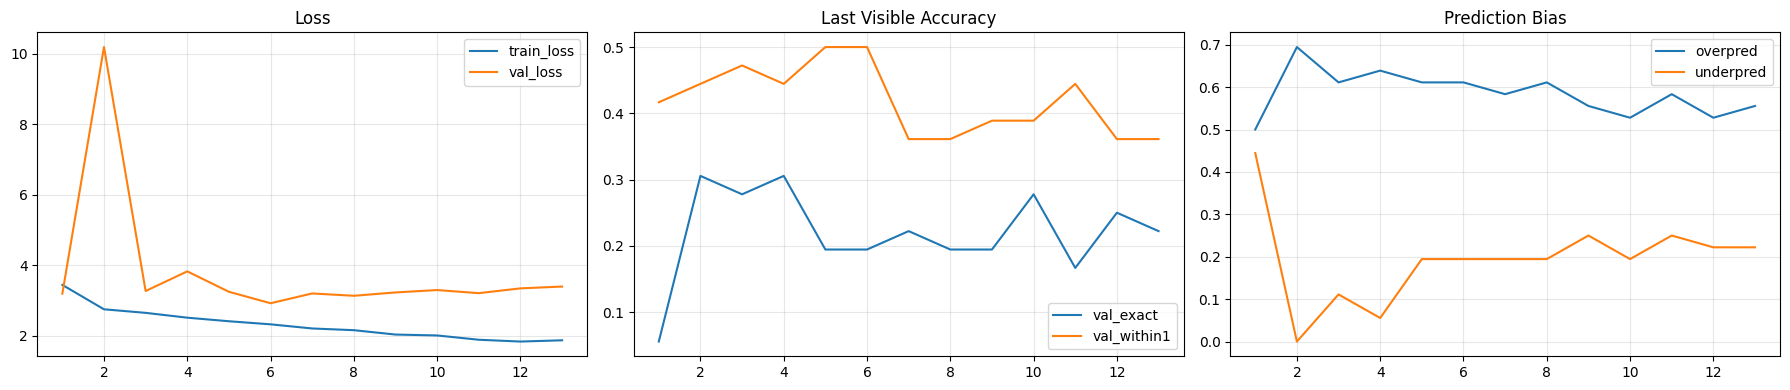

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_last_acc'], label='val_exact')
axes[1].plot(history_df['epoch'], history_df['val_last_within1_acc'], label='val_within1')
axes[1].set_title('Last Visible Accuracy')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_overprediction_rate'], label='overpred')
axes[2].plot(history_df['epoch'], history_df['val_underprediction_rate'], label='underpred')
axes[2].set_title('Prediction Bias')
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Clipping anatomico usando la ultima vertebra visible predicha

Comparamos:

- `raw`
- `prev_range_clip` de la etapa anterior, si el archivo existe
- `last_pred_clip`
- `oracle_clip`

In [11]:
prev_range_lookup = {}

if PREV_RANGE_TEST_PATH.exists():
    prev_range_df = pd.read_csv(PREV_RANGE_TEST_PATH)
    prev_range_lookup = prev_range_df.set_index("unique_sample_id").to_dict(orient="index")
    print("Se cargo referencia de visible-range estimator anterior.")
else:
    print("No se encontro archivo de range estimator anterior. Se omitira esa comparacion.")


def clip_mask_to_last_idx(mask_2d: np.ndarray, first_idx: int, last_idx: int) -> np.ndarray:
    first_idx = int(first_idx)
    last_idx = int(max(last_idx, first_idx))
    allowed_labels = canonical_labels[first_idx:last_idx + 1]
    allowed_ids = {label_to_class_id[label] for label in allowed_labels}
    out = np.zeros_like(mask_2d, dtype=np.int64)
    for class_id in allowed_ids:
        out[mask_2d == class_id] = class_id
    return out


test_gt_lookup = test_frame.set_index("unique_sample_id")[["first_visible_idx", "last_visible_idx"]].to_dict(orient="index")
last_pred_lookup = test_pred_df.set_index("unique_sample_id").to_dict(orient="index")

raw_pred_lookup = {}
oracle_clip_lookup = {}
last_pred_clip_lookup = {}
prev_range_clip_lookup = {}
target_lookup = {}
image_lookup = {}

for _, row in test_frame.iterrows():
    sample_id = row["unique_sample_id"]
    raw_mask = raw_pred_lookup_all[sample_id]
    target_mask = target_lookup_all[sample_id]
    image_roi = image_crop_lookup[sample_id]

    gt_first = int(test_gt_lookup[sample_id]["first_visible_idx"])
    gt_last = int(test_gt_lookup[sample_id]["last_visible_idx"])
    pred_last = int(last_pred_lookup[sample_id]["last_pred_idx"])

    raw_pred_lookup[sample_id] = raw_mask
    oracle_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, gt_first, gt_last)
    last_pred_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, gt_first, pred_last)
    target_lookup[sample_id] = target_mask
    image_lookup[sample_id] = image_roi

    if sample_id in prev_range_lookup:
        prev_first = int(prev_range_lookup[sample_id]["first_pred_idx"])
        prev_last = int(prev_range_lookup[sample_id]["last_pred_idx"])
        prev_range_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, prev_first, prev_last)

print("Muestras de test preparadas para clipping:", len(raw_pred_lookup))


Se cargo referencia de visible-range estimator anterior.
Muestras de test preparadas para clipping: 45


## 11. Metricas de segmentacion comparadas

In [12]:
def metrics_from_prediction_lookup(pred_lookup: dict[str, np.ndarray], target_lookup_in: dict[str, np.ndarray]) -> tuple[pd.DataFrame, pd.DataFrame]:
    intersection = np.zeros(num_classes, dtype=np.float64)
    pred_area = np.zeros(num_classes, dtype=np.float64)
    target_area = np.zeros(num_classes, dtype=np.float64)
    total_valid_correct = 0.0
    total_valid_pixels = 0.0

    for sample_id, pred_mask in pred_lookup.items():
        target_mask = target_lookup_in[sample_id]
        valid = target_mask != IGNORE_INDEX
        total_valid_correct += float((pred_mask[valid] == target_mask[valid]).sum())
        total_valid_pixels += float(valid.sum())
        for class_id in range(num_classes):
            pred_class = pred_mask[valid] == class_id
            target_class = target_mask[valid] == class_id
            intersection[class_id] += np.logical_and(pred_class, target_class).sum()
            pred_area[class_id] += pred_class.sum()
            target_area[class_id] += target_class.sum()

    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
    per_class_df = pd.DataFrame({
        'class_id': np.arange(num_classes),
        'class_name': class_names,
        'pred_pixels': pred_area,
        'target_pixels': target_area,
        'dice': dice,
        'iou': iou,
    })
    per_class_df['region'] = per_class_df['class_name'].map(
        lambda x: 'background' if x == 'background' else ('thoracic' if x.startswith('T') else 'lumbar')
    )
    fg_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
    summary_df = pd.DataFrame([
        {'metric': 'pixel_accuracy', 'value': float((total_valid_correct + 1e-6) / (total_valid_pixels + 1e-6))},
        {'metric': 'macro_dice_fg', 'value': float(fg_df['dice'].mean())},
        {'metric': 'macro_iou_fg', 'value': float(fg_df['iou'].mean())},
        {'metric': 'macro_dice_thoracic', 'value': float(fg_df.loc[fg_df['region'] == 'thoracic', 'dice'].mean())},
        {'metric': 'macro_dice_lumbar', 'value': float(fg_df.loc[fg_df['region'] == 'lumbar', 'dice'].mean())},
    ])
    return summary_df, per_class_df


raw_summary_df, raw_per_class_df = metrics_from_prediction_lookup(raw_pred_lookup, target_lookup)
oracle_summary_df, oracle_per_class_df = metrics_from_prediction_lookup(oracle_clip_lookup, target_lookup)
last_summary_seg_df, last_per_class_df = metrics_from_prediction_lookup(last_pred_clip_lookup, target_lookup)

summary_compare_df = (
    raw_summary_df.rename(columns={'value': 'raw'})
    .merge(oracle_summary_df.rename(columns={'value': 'oracle_clip'}), on='metric')
    .merge(last_summary_seg_df.rename(columns={'value': 'last_pred_clip'}), on='metric')
)
if prev_range_clip_lookup:
    prev_summary_df, prev_per_class_df = metrics_from_prediction_lookup(prev_range_clip_lookup, target_lookup)
    summary_compare_df = summary_compare_df.merge(prev_summary_df.rename(columns={'value': 'prev_range_clip'}), on='metric')
else:
    prev_per_class_df = pd.DataFrame()

display(summary_compare_df)

,metric,raw,oracle_clip,last_pred_clip,prev_range_clip
0,pixel_accuracy,0.813287,0.824241,0.817394,0.813287
1,macro_dice_fg,0.324869,0.357745,0.332359,0.324869
2,macro_iou_fg,0.201784,0.229145,0.207876,0.201784
3,macro_dice_thoracic,0.294487,0.300344,0.295631,0.294487
4,macro_dice_lumbar,0.397786,0.495506,0.420505,0.397786


## 12. Analisis por muestra: extra labels y missing labels

Esta tabla nos dira si el nuevo clipping reduce la sobreprediccion sin destruir
la segmentacion util.

In [13]:
def present_labels_from_mask(mask_2d: np.ndarray) -> list[str]:
    ids = sorted([int(x) for x in np.unique(mask_2d) if int(x) > 0])
    return [class_names[i] for i in ids]


rows = []
for _, row in test_frame.iterrows():
    sample_id = row['unique_sample_id']
    target_mask = target_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    last_mask = last_pred_clip_lookup[sample_id]

    gt_labels = present_labels_from_mask(np.where(target_mask == IGNORE_INDEX, 0, target_mask))
    raw_labels = present_labels_from_mask(raw_mask)
    oracle_labels = present_labels_from_mask(oracle_mask)
    last_labels = present_labels_from_mask(last_mask)

    record = {
        'unique_sample_id': sample_id,
        'split': row['split'],
        'image': row['image'],
        'gt_first_label': row['first_visible_label'],
        'gt_last_label': row['last_visible_label'],
        'last_pred_label': last_pred_lookup[sample_id]['last_pred_label'],
        'gt_labels': ', '.join(gt_labels),
        'raw_labels': ', '.join(raw_labels),
        'oracle_labels': ', '.join(oracle_labels),
        'last_pred_clip_labels': ', '.join(last_labels),
        'raw_extra_count': len(set(raw_labels) - set(gt_labels)),
        'oracle_extra_count': len(set(oracle_labels) - set(gt_labels)),
        'last_extra_count': len(set(last_labels) - set(gt_labels)),
        'raw_missing_count': len(set(gt_labels) - set(raw_labels)),
        'oracle_missing_count': len(set(oracle_labels) - set(gt_labels)),
        'last_missing_count': len(set(gt_labels) - set(last_labels)),
    }
    if sample_id in prev_range_clip_lookup:
        prev_labels = present_labels_from_mask(prev_range_clip_lookup[sample_id])
        record['prev_range_clip_labels'] = ', '.join(prev_labels)
        record['prev_extra_count'] = len(set(prev_labels) - set(gt_labels))
        record['prev_missing_count'] = len(set(gt_labels) - set(prev_labels))
    rows.append(record)

per_sample_compare_df = pd.DataFrame(rows)
per_sample_compare_df['last_extra_reduction_vs_raw'] = per_sample_compare_df['raw_extra_count'] - per_sample_compare_df['last_extra_count']
per_sample_compare_df['last_missing_change_vs_raw'] = per_sample_compare_df['last_missing_count'] - per_sample_compare_df['raw_missing_count']

summary_rows = [
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_oracle_extra_count', 'value': float(per_sample_compare_df['oracle_extra_count'].mean())},
    {'metric': 'mean_last_extra_count', 'value': float(per_sample_compare_df['last_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_oracle_missing_count', 'value': float(per_sample_compare_df['oracle_missing_count'].mean())},
    {'metric': 'mean_last_missing_count', 'value': float(per_sample_compare_df['last_missing_count'].mean())},
    {'metric': 'samples_with_last_extra_reduction', 'value': int((per_sample_compare_df['last_extra_reduction_vs_raw'] > 0).sum())},
    {'metric': 'samples_with_last_missing_increase', 'value': int((per_sample_compare_df['last_missing_change_vs_raw'] > 0).sum())},
]
if 'prev_extra_count' in per_sample_compare_df.columns:
    summary_rows.extend([
        {'metric': 'mean_prev_extra_count', 'value': float(per_sample_compare_df['prev_extra_count'].mean())},
        {'metric': 'mean_prev_missing_count', 'value': float(per_sample_compare_df['prev_missing_count'].mean())},
    ])

presence_summary_df = pd.DataFrame(summary_rows)
display(presence_summary_df)
display(
    per_sample_compare_df.sort_values(
        ['last_extra_reduction_vs_raw', 'last_missing_change_vs_raw', 'raw_extra_count'],
        ascending=[False, True, False],
    ).head(20)
)

,metric,value
0,mean_raw_extra_count,3.022222
1,mean_oracle_extra_count,0.000000
2,mean_last_extra_count,2.244444
3,mean_raw_missing_count,0.022222
4,mean_oracle_missing_count,0.000000
5,mean_last_missing_count,0.022222
6,samples_with_last_extra_reduction,20.000000
7,samples_with_last_missing_increase,0.000000
8,mean_prev_extra_count,3.022222
9,mean_prev_missing_count,0.022222


,unique_sample_id,split,image,gt_first_label,gt_last_label,last_pred_label,gt_labels,raw_labels,oracle_labels,last_pred_clip_labels,...,oracle_extra_count,last_extra_count,raw_missing_count,oracle_missing_count,last_missing_count,prev_range_clip_labels,prev_extra_count,prev_missing_count,last_extra_reduction_vs_raw,last_missing_change_vs_raw
28,Scoliosis__S_70.jpg,Scoliosis,S_70.jpg,T1,T6,T12,"T1, T2, T3, T4, T5, T6","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12",...,0,6,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",11,0,5,0
29,Scoliosis__S_72.jpg,Scoliosis,S_72.jpg,T1,T7,L3,"T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,8,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",10,0,2,0
20,Scoliosis__S_28.jpg,Scoliosis,S_28.jpg,T1,T8,L3,"T1, T2, T3, T4, T5, T6, T7, T8","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,7,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",9,0,2,0
26,Scoliosis__S_64.jpg,Scoliosis,S_64.jpg,T1,T10,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,5,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",7,0,2,0
43,Scoliosis__S_180.jpg,Scoliosis,S_180.jpg,T1,T10,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,5,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",7,0,2,0
19,Scoliosis__S_25.jpg,Scoliosis,S_25.jpg,T1,T12,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,3,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,2,0
21,Scoliosis__S_32.JPG,Scoliosis,S_32.JPG,T1,T12,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,3,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,2,0
22,Scoliosis__S_33.jpg,Scoliosis,S_33.jpg,T1,T12,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,3,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,2,0
42,Scoliosis__S_175.jpg,Scoliosis,S_175.jpg,T1,T12,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,3,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,2,0
40,Scoliosis__S_152.jpg,Scoliosis,S_152.jpg,T1,L1,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,2,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",4,0,2,0


## 13. Visualizacion cualitativa

Muestras seleccionadas: ['Scoliosis__S_70.jpg', 'Scoliosis__S_72.jpg', 'Scoliosis__S_28.jpg', 'Scoliosis__S_64.jpg', 'Scoliosis__S_180.jpg', 'Scoliosis__S_25.jpg', 'Scoliosis__S_32.JPG', 'Scoliosis__S_33.jpg']


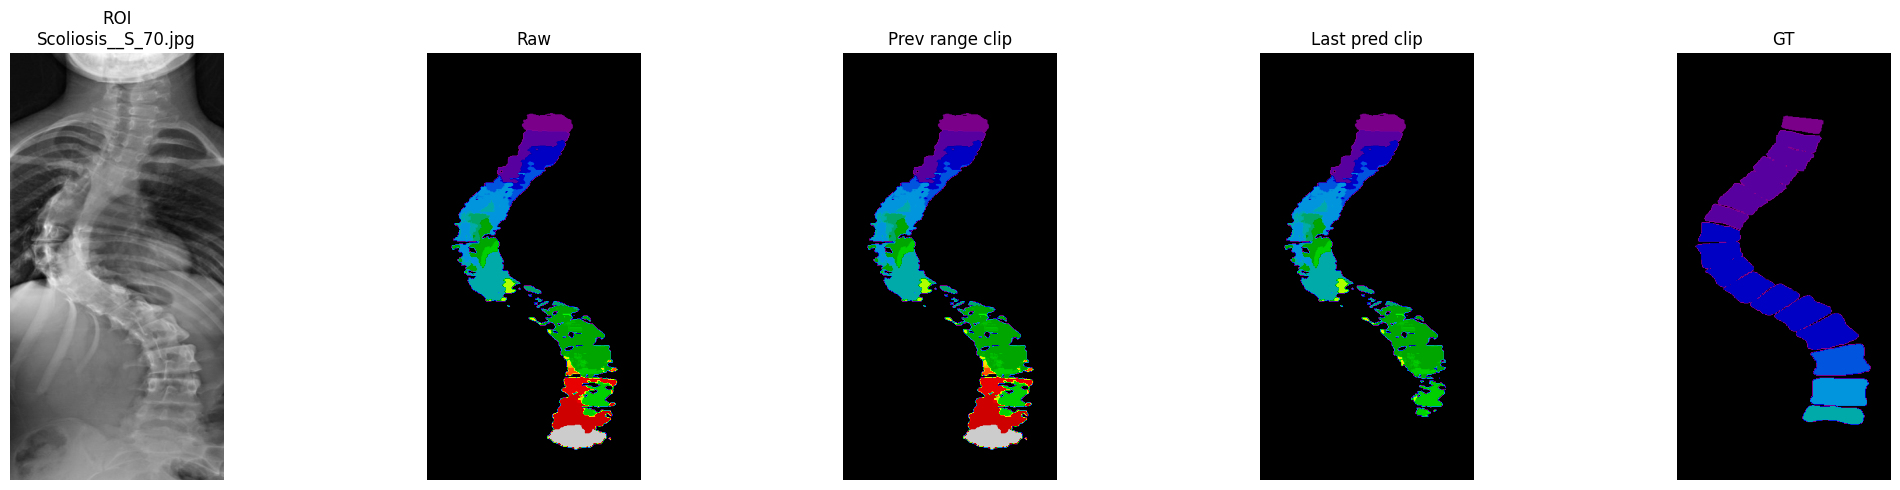

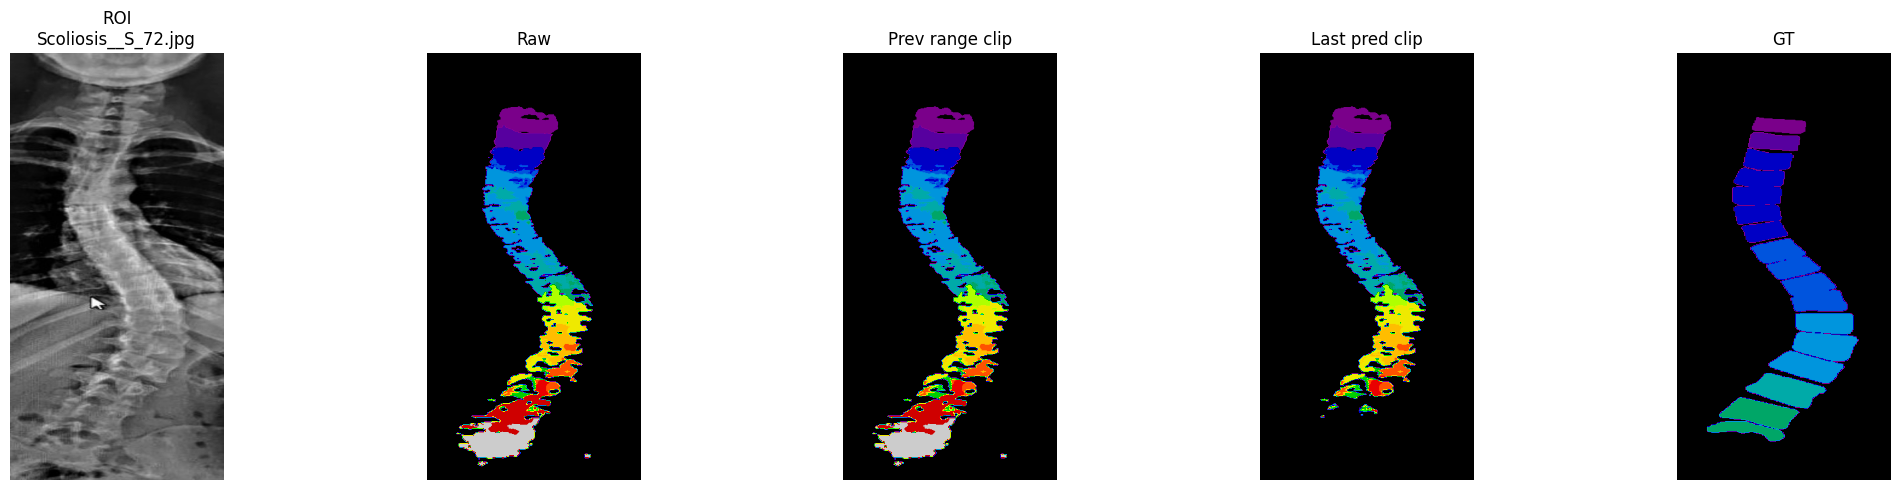

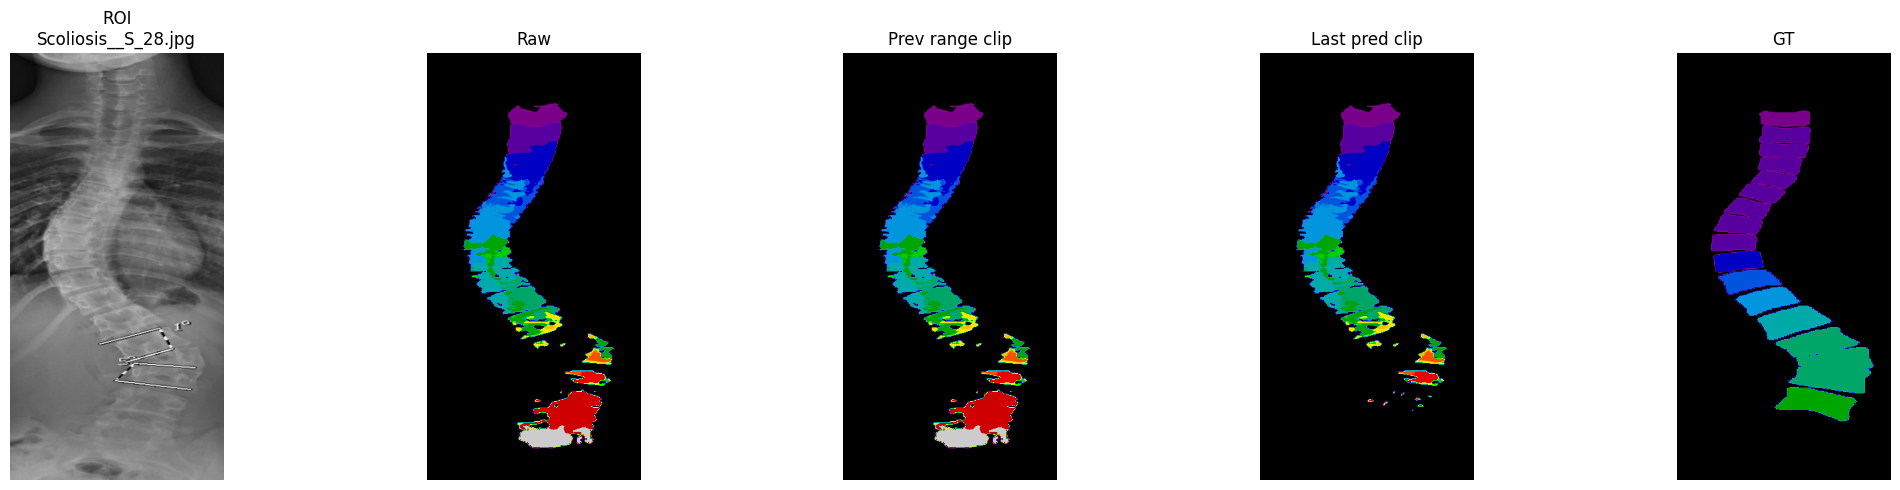

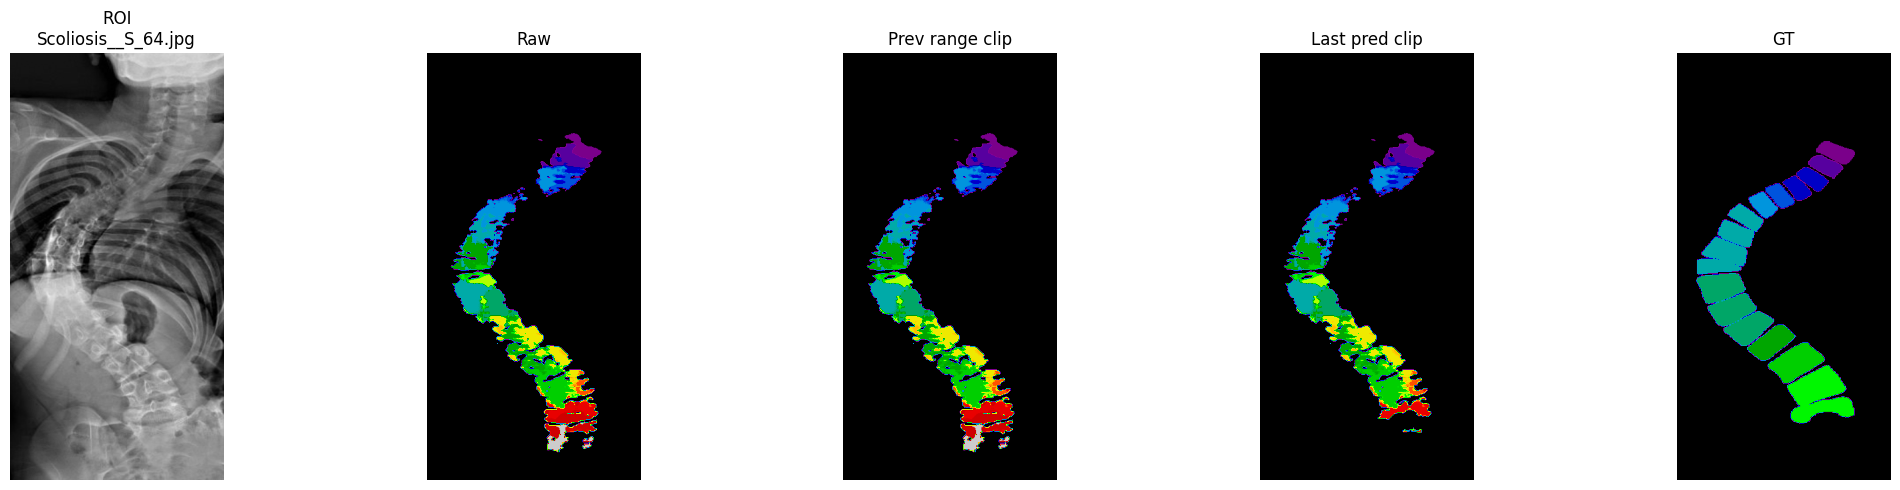

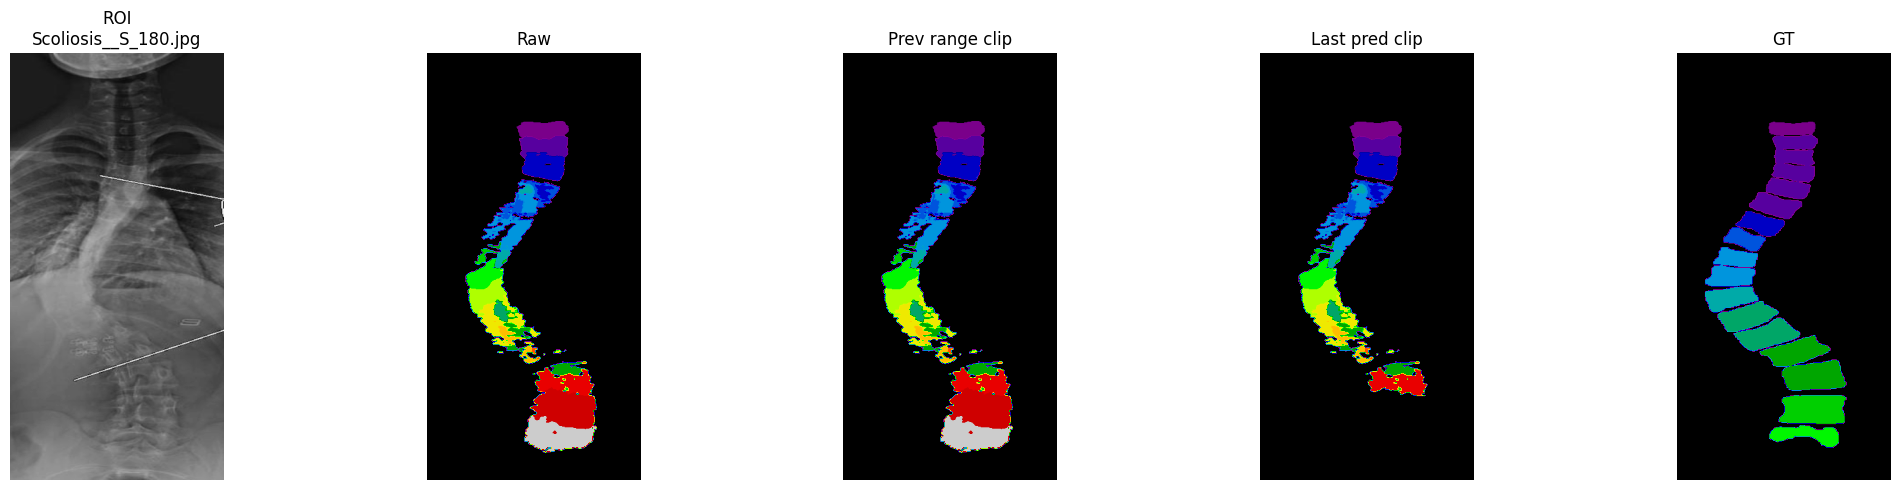

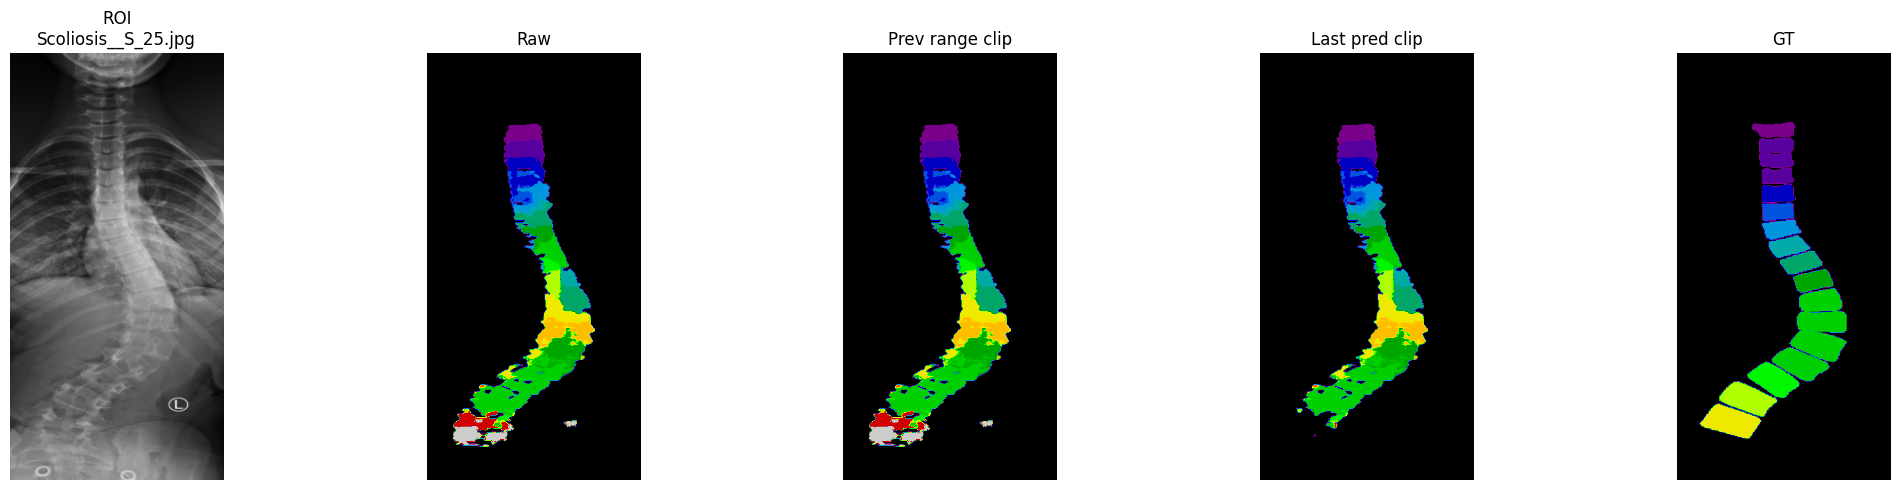

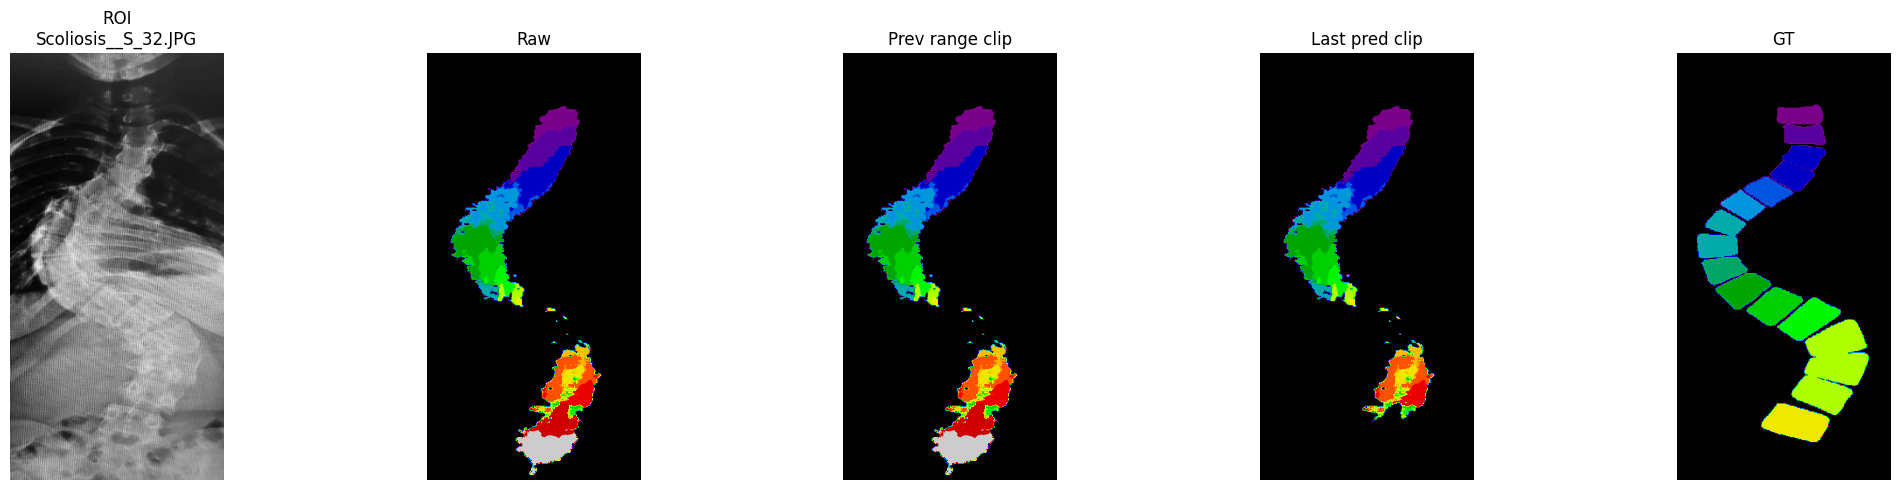

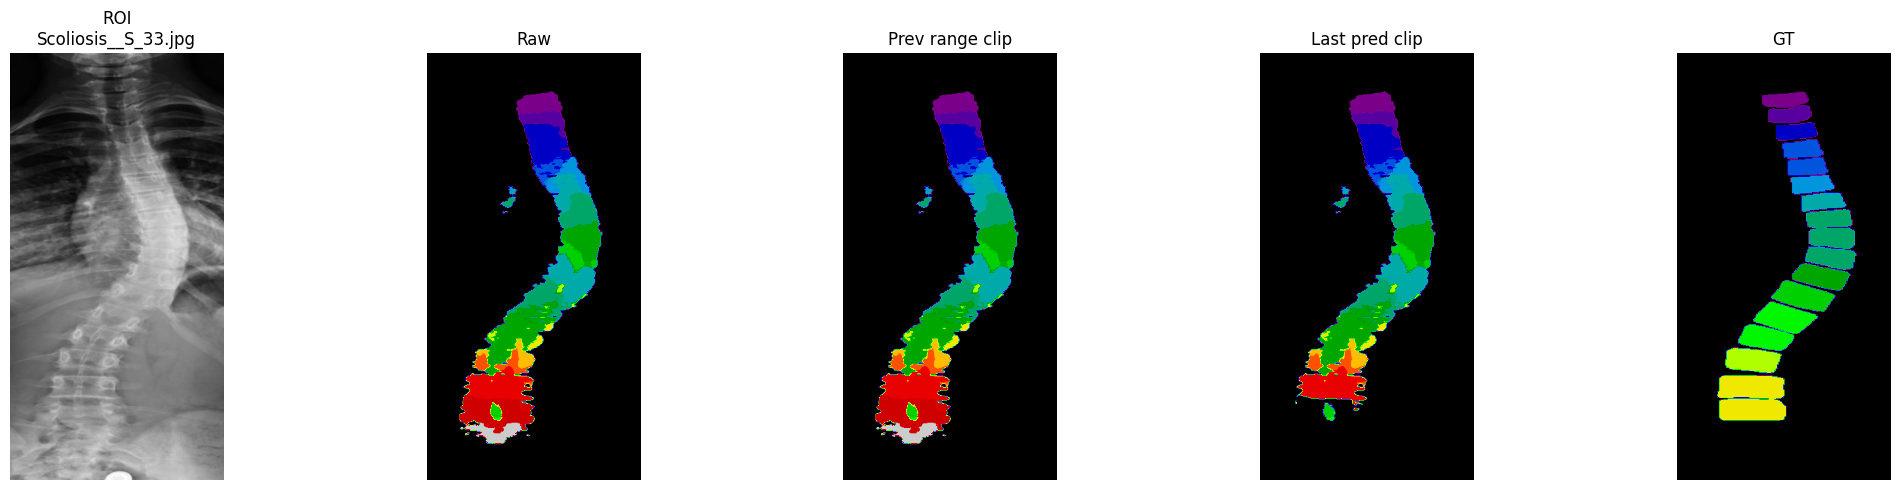

In [14]:
def show_sample(sample_id: str) -> None:
    image_gray = image_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    last_mask = last_pred_clip_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    target_mask = target_lookup[sample_id].copy()
    target_mask[target_mask == IGNORE_INDEX] = 0

    cols = 5 if sample_id in prev_range_clip_lookup else 4
    fig, axes = plt.subplots(1, cols, figsize=(4.4 * cols, 5))
    axes = np.atleast_1d(axes)
    axes[0].imshow(image_gray, cmap='gray')
    axes[0].set_title(f'ROI\n{sample_id}')
    axes[1].imshow(raw_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[1].set_title('Raw')
    offset = 2
    if sample_id in prev_range_clip_lookup:
        axes[2].imshow(prev_range_clip_lookup[sample_id], cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
        axes[2].set_title('Prev range clip')
        offset = 3
    axes[offset].imshow(last_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[offset].set_title('Last pred clip')
    axes[offset + 1].imshow(oracle_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[offset + 1].set_title('Oracle clip')
    axes[-1].imshow(target_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[-1].set_title('GT')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


sample_ids_to_show = per_sample_compare_df.sort_values(
    ['last_extra_reduction_vs_raw', 'last_missing_change_vs_raw', 'raw_extra_count'],
    ascending=[False, True, False],
)['unique_sample_id'].head(N_VIS_SAMPLES).tolist()

print('Muestras seleccionadas:', sample_ids_to_show)
for sample_id in sample_ids_to_show:
    show_sample(sample_id)

## 14. Exportacion de resultados

In [15]:
history_path = OUTPUT_DIR / 'last_visible_history.csv'
summary_path = OUTPUT_DIR / 'last_visible_summary.csv'
train_pred_path = OUTPUT_DIR / 'last_visible_train_predictions.csv'
val_pred_path = OUTPUT_DIR / 'last_visible_val_predictions.csv'
test_pred_path = OUTPUT_DIR / 'last_visible_test_predictions.csv'
compare_path = OUTPUT_DIR / 'last_visible_clipping_metric_comparison.csv'
raw_per_class_path = OUTPUT_DIR / 'last_visible_raw_per_class.csv'
oracle_per_class_path = OUTPUT_DIR / 'last_visible_oracle_per_class.csv'
last_per_class_path = OUTPUT_DIR / 'last_visible_pred_per_class.csv'
presence_path = OUTPUT_DIR / 'last_visible_presence_summary.csv'
per_sample_path = OUTPUT_DIR / 'last_visible_per_sample_compare.csv'

history_df.to_csv(history_path, index=False)
last_summary_df.to_csv(summary_path, index=False)
train_pred_df.to_csv(train_pred_path, index=False)
val_pred_df.to_csv(val_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)
summary_compare_df.to_csv(compare_path, index=False)
raw_per_class_df.to_csv(raw_per_class_path, index=False)
oracle_per_class_df.to_csv(oracle_per_class_path, index=False)
last_per_class_df.to_csv(last_per_class_path, index=False)
presence_summary_df.to_csv(presence_path, index=False)
per_sample_compare_df.to_csv(per_sample_path, index=False)

experiment_summary_df = pd.DataFrame([
    {'metric': 'target_subset', 'value': TARGET_SUBSET},
    {'metric': 'test_samples', 'value': int(len(test_frame))},
    {'metric': 'last_test_exact_acc', 'value': float(test_metrics['last_acc'])},
    {'metric': 'last_test_within1_acc', 'value': float(test_metrics['last_within1_acc'])},
    {'metric': 'last_test_mae', 'value': float(test_metrics['last_mae'])},
    {'metric': 'last_test_overprediction_rate', 'value': float(test_metrics['overprediction_rate'])},
    {'metric': 'raw_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'raw'].iloc[0])},
    {'metric': 'oracle_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'oracle_clip'].iloc[0])},
    {'metric': 'last_pred_clip_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'last_pred_clip'].iloc[0])},
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_last_extra_count', 'value': float(per_sample_compare_df['last_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_last_missing_count', 'value': float(per_sample_compare_df['last_missing_count'].mean())},
])
experiment_path = OUTPUT_DIR / 'last_visible_experiment_summary.csv'
experiment_summary_df.to_csv(experiment_path, index=False)

display(experiment_summary_df)
print('Guardado:', history_path)
print('Guardado:', summary_path)
print('Guardado:', train_pred_path)
print('Guardado:', val_pred_path)
print('Guardado:', test_pred_path)
print('Guardado:', compare_path)
print('Guardado:', raw_per_class_path)
print('Guardado:', oracle_per_class_path)
print('Guardado:', last_per_class_path)
print('Guardado:', presence_path)
print('Guardado:', per_sample_path)
print('Guardado:', experiment_path)

,metric,value
0,target_subset,partial
1,test_samples,45
2,last_test_exact_acc,0.333333
3,last_test_within1_acc,0.555556
4,last_test_mae,2.266667
5,last_test_overprediction_rate,0.644444
6,raw_macro_dice_fg,0.324869
7,oracle_macro_dice_fg,0.357745
8,last_pred_clip_macro_dice_fg,0.332359
9,mean_raw_extra_count,3.022222


Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_history.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_summary.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_train_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_val_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_test_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analys